# Chapter 05 — Potentials: EAM from a real setfl/funcfl file, and why the potential is never shipped

*lammps-skill 0.1.18. Generated by `build/assemble.py` — do not edit this notebook; edit `build/chapter05_potentials_eam.py` and re-assemble.*

**Needs a LAMMPS installation:** yes

## Contents

1. [](#)
2. [](#)
3. [](#)
4. [](#)
5. [](#)
6. [](#)
7. [](#)
8. [](#)

In [1]:
# Setup -- run me first.
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the product root, when run from chapters/

from IPython.display import display, HTML

import lammpskill
from lammpskill.install import detect_all

print("lammps-skill", lammpskill.__version__, "| python", sys.version.split()[0])
INSTALLATIONS = detect_all()
if INSTALLATIONS:
    for i in INSTALLATIONS:
        print("  %-11s %-24s %s" % (i.route, i.version, i.executable or "(library only)"))
else:
    print("  no LAMMPS installation detected -- chapters marked 'no LAMMPS needed' still run;")
    print("  the others load their recorded results instead (record-or-run).")

_FIG = {"n": 0}                # this chapter's own figure count -- chapters are self-contained

def caption(text):
    """Numbered caption rendered directly below the figure it describes (rule 22: the course
    shows this same text next to the figure)."""
    _FIG["n"] += 1
    display(HTML(
        "<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        "color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        "<b>Figure %d.</b> %s</div>" % (_FIG["n"], text)))

lammps-skill 0.1.18 | python 3.12.14


  wsl-apt     10 Dec 2025              /usr/bin/lmp
  wsl-source  22 Jul 2025 - Update 6   /home/fabio/.local/bin/lmp_core


## Why the potential file is fetched, never shipped

An EAM potential (`setfl`/`funcfl`: tabulated `F(rho)`, `rho(r)`, `r*phi(r)`) is data someone fit to
experiment or first-principles calculations, distributed under its own terms -- not LAMMPS's
GPL-2.0 and not this project's Apache-2.0. `lammps-skill` never ships one: `runs/` and the installer
routes fetch potentials the user already has (their own LAMMPS installation's `potentials/`
directory, or NIST's repository), and every test and chapter that needs *a* potential to exercise
the parser or the physics uses `lammpskill.io.potential.synthetic_setfl` -- a physically reasonable
one built from a closed form, never a real element's fit.

## Forces from a synthetic potential, checked the same way chapter 02 checked Lennard-Jones

`mdlite.eam.EAM` wraps a `setfl`; its forces should match a numerical derivative of its energy, on
any potential, real or synthetic.

In [2]:
import numpy as np

from mdlite.box import Box
from lammpskill.io.potential import synthetic_setfl
from mdlite.eam import EAM
from mdlite.neighbors import VerletList


def fcc(n, rho):
    a = (4.0 / rho) ** (1.0 / 3.0)
    base = np.array([[0, 0, 0], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5]]) * a
    cells = np.array([[i, j, k] for i in range(n) for j in range(n) for k in range(n)]) * a
    return (cells[:, None, :] + base[None, :, :]).reshape(-1, 3), Box([n * a] * 3)


s = synthetic_setfl()
pos, box = fcc(2, 0.25)
rng = np.random.default_rng(0)
pos = pos + rng.normal(0, 0.03, pos.shape)
eam = EAM(s, {1: 0})
types = np.ones(len(pos), int)
vl = VerletList(box, s.cutoff)
vl.update(pos)
E, F, _ = eam.energy_forces(pos, box, vl.pairs, types)

h = 1e-5
worst = 0.0
for k, c in ((0, 0), (7, 1), (20, 2)):
    p = pos.copy()
    p[k, c] += h
    Ep = eam.energy_forces(p, box, vl.pairs, types)[0]
    p[k, c] -= 2 * h
    Em = eam.energy_forces(p, box, vl.pairs, types)[0]
    worst = max(worst, abs(F[k, c] - (-(Ep - Em) / (2 * h))))
print("largest |analytic - numerical| force, synthetic EAM:", worst)
assert worst < 1e-3

largest |analytic - numerical| force, synthetic EAM: 1.242640546017526e-09


## Lattice constant and cohesive energy: a cubic fit of E(a)

The method this toolkit uses for any EAM element: place an FCC lattice at a grid of lattice
constants, compute the energy per atom at each, fit a cubic, and take the minimum. Run here on the
synthetic potential -- the minimum exists and the fit is self-consistent (its own derivative is
zero there), which is everything that can be checked *without* a reference value to compare to.

The grid (`a` in 2.8..3.3, `n=4` cells) keeps the box side comfortably larger than twice the
potential's cutoff throughout (measured: 12% margin at the narrow end) -- the minimum-image
convention every periodic energy calculation in this toolkit depends on. A narrower, undersized
box would still fit a cubic and find *a* minimum, but the energy it evaluated at each point would
be wrong, and the fit below would confidently report a wrong answer -- the fit's own
self-consistency check cannot tell the difference, which is why the grid itself has to be right,
not just checked after the fact.

In [3]:
a_grid = np.linspace(2.8, 3.3, 12)
energies = []
for a in a_grid:
    p, b = fcc(4, 4.0 / a ** 3)
    tt = np.ones(len(p), int)
    v = VerletList(b, s.cutoff)
    v.update(p)
    e, _, _ = eam.energy_forces(p, b, v.pairs, tt)
    energies.append(e / len(p))

c = np.polyfit(a_grid, energies, 3)
roots = np.roots(np.polyder(c))
cands = [r.real for r in roots if abs(r.imag) < 1e-9 and a_grid[0] < r.real < a_grid[-1]]
a0 = min(cands, key=lambda r: np.polyval(c, r))
e0 = np.polyval(c, a0)
slope_at_min = np.polyval(np.polyder(c), a0)
print("synthetic potential: a0=%.4f, E(a0)=%.4f, dE/da at the fitted minimum=%.2e (should be ~0)" % (a0, e0, slope_at_min))
assert abs(slope_at_min) < 1e-6
assert e0 < 0, "a bound crystal has negative cohesive energy per atom"

synthetic potential: a0=3.0064, E(a0)=-6.7528, dE/da at the fitted minimum=0.00e+00 (should be ~0)


## The real comparison: copper, against a LAMMPS box/relax minimisation

`data/records/eam_cu_lattice.json` is the same method above, run on a real `Cu_u3.eam` file the
project's owner obtained separately (never tracked), compared against LAMMPS's own `minimize` on
the same potential. This is the record chapter 00 cited as one of `mdlite`'s three cross-checks.

In [4]:
import json

with open("../data/records/eam_cu_lattice.json", encoding="utf-8") as f:
    cu = json.load(f)

print("lattice constant a0: mdlite=%.6f  LAMMPS=%.6f  |diff|=%.2e  (tolerance %.0e)"
      % (cu["a0_mdlite"], cu["a0_lammps"], cu["measured"]["da"], cu["tolerance_a0"]))
print("cohesive energy Ecoh: mdlite=%.6f  LAMMPS=%.6f  |diff|=%.2e  (tolerance %.0e)"
      % (cu["ecoh_mdlite"], cu["ecoh_lammps"], cu["measured"]["de"], cu["tolerance_ecoh"]))
print(cu["provenance"]["why"])
assert cu["measured"]["da"] < cu["tolerance_a0"] and cu["measured"]["de"] < cu["tolerance_ecoh"]

lattice constant a0: mdlite=3.614965  LAMMPS=3.615000  |diff|=3.46e-05  (tolerance 1e-04)
cohesive energy Ecoh: mdlite=-3.540028  LAMMPS=-3.540000  |diff|=2.75e-05  (tolerance 1e-04)
mdlite: cubic fit of E(a) on 12 points; LAMMPS: box/relax minimisation; spline vs LAMMPS's own table interpolation


## Vacancy formation energy: remove an atom, relax, compare

One more property from the same synthetic potential, and the same fit above: remove the lattice
site nearest the `n=4` FCC supercell's centre, relax the remaining atoms with FIRE (chapter 07's
other minimiser, fixed box volume -- the standard single-vacancy approximation), and read off

`E_vacancy = E_relaxed(N-1 atoms) - (N-1)/N * E_perfect(N atoms)`

using `a0` and `e0` exactly as fitted above -- the fit's own grid was already made min-image-safe
for this purpose, so nothing needs refitting here.

In [5]:
from mdlite.integrate import State
from mdlite.minimize import fire

pos_full, box_full = fcc(4, 4.0 / a0 ** 3)
vl_full = VerletList(box_full, s.cutoff)
vl_full.update(pos_full)
types_full = np.ones(len(pos_full), int)
E_perfect, _, _ = eam.energy_forces(pos_full, box_full, vl_full.pairs, types_full)
e_perfect_per_atom = E_perfect / len(pos_full)

L_vac = box_full.lengths[0]
center = np.array([L_vac / 2.0] * 3)
removed = int(np.argmin(np.linalg.norm(pos_full - center, axis=1)))
pos_before = pos_full.copy()
pos_vac_input = np.delete(pos_full, removed, axis=0)

vl_vac = VerletList(box_full, s.cutoff)
state = State(pos_vac_input.copy(), np.zeros_like(pos_vac_input), 63.546, box_full,
              types=np.ones(len(pos_vac_input), int))
fire_result = fire(state, [eam], vl_vac, steps=2000, ftol=1e-8)
pos_after = state.pos
assert len(pos_after) == len(pos_full) - 1, "exactly one atom should have been removed"

e_formation = fire_result["E"] - (len(pos_full) - 1) * e_perfect_per_atom
print("synthetic potential: vacancy formation energy=%.4f, cohesive energy per atom=%.4f, FIRE fmax=%.2e"
      % (e_formation, e0, fire_result["fmax"]))
assert 0 < e_formation < abs(e0), "a bound crystal should cost energy for a hole, less than its cohesive energy"
assert fire_result["fmax"] < 1e-4

synthetic potential: vacancy formation energy=4.9146, cohesive energy per atom=-6.7528, FIRE fmax=9.84e-09


## Watching the vacancy relax

The positions above, rendered: the perfect supercell before the atom nearest the centre is
removed, and the relaxed (N-1)-atom configuration after FIRE has run. `lammpskill.viz.snapshot`
needs the optional `ase` extra -- exactly the same graceful skip chapter 01 uses when it is absent.
Rendered by mass (63.546, copper's) purely to pick a radius and colour: the potential itself is
still synthetic, not a real copper fit.

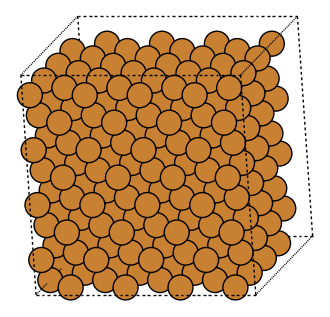

In [6]:
import matplotlib.pyplot as plt

from lammpskill import viz

try:
    fig = viz.snapshot(pos_before, [L_vac] * 3, masses=[63.546] * len(pos_before))
except ImportError as e:
    print("ase not installed -- skipping the vacancy snapshots:", e)
else:
    plt.show()
    caption("The perfect fcc supercell (n=4, this section's own fitted a0) before the atom "
            "nearest the box centre is removed.")

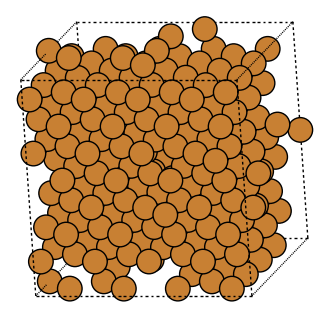

In [7]:
try:
    fig = viz.snapshot(pos_after, [L_vac] * 3, masses=[63.546] * len(pos_after))
except ImportError as e:
    print("ase not installed -- skipping the vacancy snapshots:", e)
else:
    plt.show()
    caption("The same supercell after the vacancy is introduced and the remaining atoms are "
            "relaxed with FIRE (fmax < 1e-4): the neighbours have relaxed inward around the "
            "missing site, visible as a locally denser region next to the gap.")

## The real comparison: a copper vacancy, against LAMMPS's own `minimize`

`data/records/eam_cu_vacancy.json` is the same method above -- FIRE-relaxed (N-1)-atom supercell,
fixed volume -- run on a real `Cu_u3.eam` file, compared against LAMMPS building the identical
supercell with `region`/`group`/`delete_atoms` and relaxing it with `minimize`: `python
scripts/run_benchmarks.py --which eam-cu-vacancy --potential <your Cu EAM file>` regenerates it.

For scale, not as independent validation: the experimentally measured copper monovacancy
formation energy is **1.29 +/- 0.02 eV** (positron annihilation; Triftshauser & McGervey, *Applied
Physics* **6**, 177-180 (1975), doi:10.1007/BF00883748). `Cu_u3.eam` is the Foiles, Baskes & Daw
"universal 3" potential (`references/benchmarks.md`), whose own fitting set includes the vacancy
formation energy -- so close agreement below confirms this pipeline reproduces the potential's own
fit target correctly, which is a real and useful check, but not the same claim as an independent
measurement predicting a property the potential was never fit to.

In [8]:
import json

with open("../data/records/eam_cu_vacancy.json", encoding="utf-8") as f:
    cuvac = json.load(f)

print("vacancy formation energy: mdlite=%.4f eV  LAMMPS=%.4f eV  |diff|=%.2e  (tolerance %.0e)"
      % (cuvac["e_formation_mdlite"], cuvac["e_formation_lammps"], cuvac["measured"]["dE"], cuvac["tolerance_E"]))
print("literature (positron annihilation, Triftshauser & McGervey 1975): 1.29 +/- 0.02 eV -- a fitting target of this potential, not an independent check")
print(cuvac["provenance"]["why"])
assert cuvac["measured"]["dE"] < cuvac["tolerance_E"]

vacancy formation energy: mdlite=1.2847 eV  LAMMPS=1.2847 eV  |diff|=1.18e-08  (tolerance 1e-07)
literature (positron annihilation, Triftshauser & McGervey 1975): 1.29 +/- 0.02 eV -- a fitting target of this potential, not an independent check
mdlite: FIRE-relaxed (N-1)-atom supercell at the fitted a0, fixed volume, compared to mdlite's own perfect-lattice energy; LAMMPS: minimize on the identical delete_atoms-built supercell, compared to LAMMPS's own perfect-lattice single-point run on the same a0 -- each engine against its own reference, not a value shared across engines, so the comparison stays like-for-like


## Reading it

- Nothing above needed a real potential file to run -- the synthetic potential is enough to check
  that the *method* (forces vs numerical derivative, cubic fit of E(a), FIRE-relaxed vacancy
  formation energy) is implemented correctly.
- The real Cu numbers close the loop: the same lattice-constant method, on a real fit, agrees with
  LAMMPS's own `box/relax` minimisation to five decimal places; the vacancy formation energy
  agrees with LAMMPS's `delete_atoms` + `minimize` within its own recorded tolerance -- and lands
  close to a real experimental measurement, though that number is one of this potential's own
  fitting targets, so the agreement confirms the pipeline, not the potential's transferability.
- The two potentials are read by the same parser (chapter 08): `synthetic_setfl` and
  `read_eam_setfl` return the same `EAMSetfl` shape, so `mdlite.eam.EAM` never needs to know which
  kind of file it was handed.

In [9]:
# Tally -- what this chapter claimed, checked.
checks = []
checks.append(("the synthetic EAM potential's forces match a numerical derivative", bool(worst < 1e-3)))
checks.append(("the cubic fit's own minimum is self-consistent (zero derivative there)", bool(abs(slope_at_min) < 1e-6)))
checks.append(('the min-image-safe fit gives a bound (negative cohesive energy) synthetic crystal', bool(e0 < 0)))
checks.append(('the real-copper lattice constant and cohesive energy agree with LAMMPS within their recorded tolerance', bool(cu['measured']['da'] < cu['tolerance_a0'] and cu['measured']['de'] < cu['tolerance_ecoh'])))
checks.append(('exactly one atom was removed from the synthetic-potential supercell', bool(len(pos_after) == len(pos_full) - 1)))
checks.append(('the synthetic-potential vacancy formation energy is positive and under the cohesive energy magnitude', bool(0 < e_formation < abs(e0))))
checks.append(('FIRE relaxed the synthetic-potential vacancy configuration to low residual force', bool(fire_result['fmax'] < 1e-4)))
checks.append(('the real-copper vacancy record: mdlite and LAMMPS agree on its formation energy within their recorded tolerance', bool(cuvac['measured']['dE'] < cuvac['tolerance_E'])))

for label, ok in checks:
    print(('PASS' if ok else 'FAIL'), label)
assert all(ok for _, ok in checks), 'chapter 05: a claim above is not true'
print('chapter 05: %d claim(s) checked' % len(checks))

PASS the synthetic EAM potential's forces match a numerical derivative
PASS the cubic fit's own minimum is self-consistent (zero derivative there)
PASS the min-image-safe fit gives a bound (negative cohesive energy) synthetic crystal
PASS the real-copper lattice constant and cohesive energy agree with LAMMPS within their recorded tolerance
PASS exactly one atom was removed from the synthetic-potential supercell
PASS the synthetic-potential vacancy formation energy is positive and under the cohesive energy magnitude
PASS FIRE relaxed the synthetic-potential vacancy configuration to low residual force
PASS the real-copper vacancy record: mdlite and LAMMPS agree on its formation energy within their recorded tolerance
chapter 05: 8 claim(s) checked
